# Iowa N Load Pipeline v4 — corrected

From v3, plus review round 2: (5a) renamed the clobbered `site_month`; (1) exports coverage-screened primary (`county_year_load_primary.csv`, >=50% coverage) alongside the full sample and full-area sensitivity, and reports all three means; (5b) the within/intersects sensitivity now uses the covered-area denominator.


# Iowa County Nitrogen Load — Final Pipeline

Single, auditable rebuild of the county-scale nitrogen load dataset. Replaces the load-building
sections of `County_LOAD.ipynb` and `NewFlow.ipynb`.

**Primary estimator (same-HUC):**

$$L_{iht} = Q_{ht}\times C_{ht}\times 0.01\times A_{ih}$$

$Q_{ht}$ = monthly runoff depth (mm) for HUC8 $h$; $C_{ht}$ = monthly mean nitrate-N (mg/L) for the
**same** HUC8 and month; $A_{ih}$ = area (ha) of the county $i$ / HUC8 $h$ intersection.
The constant 0.01 converts mm x mg/L x ha to kg N.

County-month load = sum of piece loads / county area (kg/ha).
County-year load = sum over months with valid data. Never zero-filled.

**Standing decisions**

| # | Decision |
|---|---|
| D1 | Same-HUC estimator is primary. Flow and concentration are joined on `(HUC_8, Year, Month)` before any county allocation, so cross-HUC pairing is structurally impossible. |
| D2 | Counties with no same-HUC data are **excluded**, not imputed and not zero-filled. |
| D3 | `Obrien` is normalised to `O'Brien` at every ingest point. |
| D4 | Coverage fraction is recorded for every county-month and county-year. |
| D5 | Flow units and mean load magnitude are asserted against published Iowa values. |
| D6 | Gauge-to-HUC8 join uses `within`. `intersects` is available as sensitivity only. |

**Sections**

0. Setup and configuration
1. Geometry - counties, HUC8s, intersection pieces
2. Streamflow - USGS NWIS
3. Concentration - Iowa DNR
4. Coverage diagnostic - the same-HUC decision point
5. Load
6. Precipitation - IEM
7. Nitrogen surplus and tile drainage
8. Panel assembly
9. Methods audit tables
10. Export

## 0. Setup and configuration

In [1]:
import os, io, json, time, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
from shapely.geometry import Point

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

CFG = dict(
    START_YEAR = 2000,
    END_YEAR   = 2020,
    CRS        = "EPSG:26915",       # NAD83 / UTM 15N - metric, for areas

    # unit constants
    KG_PER_MM_HA_PER_MGL = 0.01,     # 1 mm over 1 ha at 1 mg/L = 0.01 kg N
    CFS_TO_M3S           = 0.0283168,
    MI2_TO_M2            = 2.58999e6,
    ACRE_TO_HA           = 0.404686,

    # concentration handling
    CONVERT_NO3_TO_NO3N = False,     # True if `result` is NO3 rather than NO3-N
    NO3_TO_N            = 0.2259,
    CONC_MAX_MGL        = 100.0,     # implausible above this

    # quality thresholds
    MIN_DAYS_PER_SITE_MONTH = 25,
    COMPLETE_YEAR_MONTHS    = 12,
    MIN_PIECE_HA            = 1.0,   # drop overlay slivers

    # switches
    GAUGE_PREDICATE   = "within",    # 'within' | 'intersects'  (D6)
    EXCLUDE_NO_SAME_HUC = True,      # D2
    PRECIP_FALLBACK_NEAREST = True,  # counties with no COOP station

    DATA = "data",
    OUT  = "out",
    CACHE = "cache",
)

for d in [CFG["OUT"], CFG["CACHE"]]:
    os.makedirs(d, exist_ok=True)

LOG = []
def log(msg, decision=False):
    line = f"[{datetime.now():%H:%M:%S}] {'DECISION' if decision else '        '} {msg}"
    print(line); LOG.append(line)

def save_log():
    with open(f"{CFG['OUT']}/decision_log.txt", "w") as f:
        f.write("\n".join(LOG) + "\n")
    print(f"\nwrote {CFG['OUT']}/decision_log.txt  ({len(LOG)} lines)")

COUNTY_FIXES = {"Obrien":"O'Brien","OBrien":"O'Brien","O Brien":"O'Brien","O'brien":"O'Brien"}

def norm_county(s):
    return s.astype(str).str.strip().str.title().replace(COUNTY_FIXES)

def norm_huc(s):
    return s.astype(str).str.extract(r"(\d+)", expand=False).str.zfill(8)

log("=" * 68)
log(f"Iowa nitrogen load pipeline  |  {datetime.now():%Y-%m-%d %H:%M}")
log(f"period {CFG['START_YEAR']}-{CFG['END_YEAR']}  CRS {CFG['CRS']}")
log("=" * 68)

[15:28:05]          ====================================================================
[15:28:05]          Iowa nitrogen load pipeline  |  2026-07-26 15:28
[15:28:05]          period 2000-2020  CRS EPSG:26915
[15:28:05]          ====================================================================


## 1. Geometry — counties, HUC8s, intersection pieces

Load county and HUC8 boundaries, normalise names, project to a metric CRS, and build the
county x HUC8 intersection table. `area_ha_piece` is the weight used for every later allocation.

Uses local shapefiles if present, otherwise the Iowa Geospatial Data Clearinghouse services.

In [2]:
# ======================================================
# LOAD COUNTY AND HUC-8 BOUNDARIES
# ======================================================

import os
from pathlib import Path

import requests
import geopandas as gpd


def arcgis_geojson(
    query_url,
    dataset_name,
    timeout=180
):
    """
    Download an ArcGIS feature layer as a GeoDataFrame.

    Parameters
    ----------
    query_url : str
        Full ArcGIS REST query endpoint ending in /query.
    dataset_name : str
        Descriptive name used in error messages.
    timeout : int
        Request timeout in seconds.

    Returns
    -------
    geopandas.GeoDataFrame
    """

    params = {
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "true",
        "outSR": "4326",
        "f": "geojson",
    }

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 "
            "(KHTML, like Gecko) Chrome/150.0 Safari/537.36"
        ),
        "Accept": "application/geo+json, application/json",
    }

    try:
        response = requests.get(
            query_url,
            params=params,
            headers=headers,
            timeout=timeout,
        )

    except requests.RequestException as exc:
        raise RuntimeError(
            f"Could not connect to the ArcGIS service for "
            f"{dataset_name}: {exc}"
        ) from exc

    # Give a useful error rather than only "400 Bad Request"
    if not response.ok:
        try:
            server_message = response.json()
        except ValueError:
            server_message = response.text[:1000]

        raise RuntimeError(
            f"ArcGIS request failed for {dataset_name}.\n"
            f"HTTP status: {response.status_code}\n"
            f"Request URL: {response.url}\n"
            f"Server response: {server_message}"
        )

    try:
        geojson = response.json()
    except ValueError as exc:
        raise RuntimeError(
            f"The {dataset_name} service did not return valid JSON."
        ) from exc

    # ArcGIS can return HTTP 200 but still include an error object
    if "error" in geojson:
        error_info = geojson["error"]

        raise RuntimeError(
            f"ArcGIS returned an error for {dataset_name}: "
            f"{error_info}"
        )

    if geojson.get("type") != "FeatureCollection":
        raise RuntimeError(
            f"The response for {dataset_name} is not a "
            f"GeoJSON FeatureCollection."
        )

    features = geojson.get("features", [])

    if not features:
        raise RuntimeError(
            f"The ArcGIS service returned no {dataset_name} features."
        )

    gdf = gpd.GeoDataFrame.from_features(
        features,
        crs="EPSG:4326",
    )

    if gdf.empty:
        raise RuntimeError(
            f"The resulting {dataset_name} GeoDataFrame is empty."
        )

    return gdf


def find_existing_file(paths):
    """
    Return the first existing path from a list of candidates.
    """
    for path in paths:
        path = Path(path)

        if path.exists():
            return path

    return None


def standardize_counties(counties):
    """
    Create a consistent CountyName column.
    """

    county_name_candidates = [
        "CountyName",
        "unitName",
        "COUNTY",
        "COUNTYNAME",
        "NAME",
        "Name",
        "County",
    ]

    county_column = next(
        (
            column
            for column in county_name_candidates
            if column in counties.columns
        ),
        None,
    )

    if county_column is None:
        raise KeyError(
            "A county-name column could not be identified.\n"
            f"Available columns: {counties.columns.tolist()}"
        )

    counties = counties.copy()

    counties["CountyName"] = (
        counties[county_column]
        .astype(str)
        .str.strip()
        .str.replace(
            r"\s+County$",
            "",
            regex=True,
            case=False,
        )
        .str.title()
    )

    counties = counties.loc[
        counties.geometry.notna()
        & ~counties.geometry.is_empty
    ].copy()

    # Dissolve only if the service contains multiple pieces per county
    counties = (
        counties[
            ["CountyName", "geometry"]
        ]
        .dissolve(
            by="CountyName",
            as_index=False,
        )
    )

    counties = counties.to_crs("EPSG:4326")

    return counties


def standardize_hucs(hucs):
    """
    Create a consistent HUC_8 column.
    """

    huc_candidates = [
        "HUC_8",
        "HUC8",
        "huc_8",
        "huc8",
        "HUC_08",
        "HU_8",
    ]

    huc_column = next(
        (
            column
            for column in huc_candidates
            if column in hucs.columns
        ),
        None,
    )

    if huc_column is None:
        raise KeyError(
            "A HUC-8 identifier column could not be identified.\n"
            f"Available columns: {hucs.columns.tolist()}"
        )

    hucs = hucs.copy()

    # Preserve leading zeros and remove accidental decimal endings
    hucs["HUC_8"] = (
        hucs[huc_column]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(8)
    )

    hucs = hucs.loc[
        hucs["HUC_8"].notna()
        & hucs.geometry.notna()
        & ~hucs.geometry.is_empty
    ].copy()

    # Combine multipart records belonging to the same HUC-8
    hucs = (
        hucs[
            ["HUC_8", "geometry"]
        ]
        .dissolve(
            by="HUC_8",
            as_index=False,
        )
    )

    hucs = hucs.to_crs("EPSG:4326")

    return hucs


def load_boundaries():
    """
    Load Iowa counties and HUC-8 watersheds.

    Priority:
    1. Existing local files.
    2. Previously downloaded GeoJSON files.
    3. Iowa DNR ArcGIS services.
    """

    data_root = Path(CFG["DATA"])

    # --------------------------------------------------
    # Possible local county files
    # --------------------------------------------------
    county_candidates = [
        data_root
        / "Iowa_County_Boundaries"
        / "IowaCounties.shp",

        data_root
        / "IowaCounties.shp",

        data_root
        / "Iowa_County_Boundaries"
        / "iowa_counties.geojson",

        data_root
        / "iowa_counties.geojson",
    ]

    # --------------------------------------------------
    # Possible local HUC-8 files
    # --------------------------------------------------
    huc_candidates = [
        data_root
        / "WBD_IA"
        / "WBD_HU_08_IA.shp",

        data_root
        / "WBD_HU_08_IA.shp",

        data_root
        / "huc8_watersheds"
        / "iowa_huc8_watersheds.geojson",

        Path("huc8_watersheds")
        / "iowa_huc8_watersheds.geojson",
    ]

    county_path = find_existing_file(
        county_candidates
    )

    huc_path = find_existing_file(
        huc_candidates
    )

    logger = globals().get("log", print)

    # --------------------------------------------------
    # Load counties
    # --------------------------------------------------
    if county_path is not None:
        counties = gpd.read_file(
            county_path
        )

        logger(
            f"Counties loaded from local file: "
            f"{county_path}"
        )

    else:
        county_query_url = (
            "https://programs.iowadnr.gov/geospatial/"
            "rest/services/reference/ManagementBoundaries/"
            "MapServer/0/query"
        )

        counties = arcgis_geojson(
            query_url=county_query_url,
            dataset_name="Iowa counties",
        )

        logger(
            "Counties downloaded from the "
            "Iowa DNR ArcGIS service."
        )

    # --------------------------------------------------
    # Load HUC-8 watersheds
    # --------------------------------------------------
    if huc_path is not None:
        hucs = gpd.read_file(
            huc_path
        )

        logger(
            f"HUC-8 watersheds loaded from local file: "
            f"{huc_path}"
        )

    else:
        huc_query_url = (
            "https://programs.iowadnr.gov/geospatial/"
            "rest/services/SurfaceWaters/Watersheds/"
            "MapServer/3/query"
        )

        hucs = arcgis_geojson(
            query_url=huc_query_url,
            dataset_name="Iowa HUC-8 watersheds",
        )

        logger(
            "HUC-8 watersheds downloaded from the "
            "Iowa DNR ArcGIS service."
        )

    # --------------------------------------------------
    # Standardize columns and CRS
    # --------------------------------------------------
    counties = standardize_counties(
        counties
    )

    hucs = standardize_hucs(
        hucs
    )

    # --------------------------------------------------
    # Validation
    # --------------------------------------------------
    if counties["CountyName"].nunique() != 99:
        raise ValueError(
            "Expected 99 Iowa counties, but found "
            f"{counties['CountyName'].nunique()}."
        )

    if counties.crs != hucs.crs:
        hucs = hucs.to_crs(
            counties.crs
        )

    logger(
        f"Boundary loading complete: "
        f"{len(counties)} counties and "
        f"{len(hucs)} HUC-8 watersheds."
    )

    return counties, hucs


# ======================================================
# RUN
# ======================================================

counties_raw, hucs_raw = load_boundaries()

print(
    "\nCounty shape:",
    counties_raw.shape
)

print(
    "HUC-8 shape:",
    hucs_raw.shape
)

print(
    "County CRS:",
    counties_raw.crs
)

print(
    "HUC-8 CRS:",
    hucs_raw.crs
)

print(
    "\nCounty columns:",
    counties_raw.columns.tolist()
)

print(
    "HUC columns:",
    hucs_raw.columns.tolist()
)

print(
    "\nCounty sample:"
)

print(
    counties_raw[
        ["CountyName"]
    ].head()
)

print(
    "\nHUC-8 sample:"
)

print(
    hucs_raw[
        ["HUC_8"]
    ].head()
)

[15:28:14]          Counties loaded from local file: data\Iowa_County_Boundaries\IowaCounties.shp
[15:28:14]          HUC-8 watersheds loaded from local file: data\WBD_IA\WBD_HU_08_IA.shp
[15:28:14]          Boundary loading complete: 99 counties and 57 HUC-8 watersheds.

County shape: (99, 2)
HUC-8 shape: (57, 2)
County CRS: EPSG:4326
HUC-8 CRS: EPSG:4326

County columns: ['CountyName', 'geometry']
HUC columns: ['HUC_8', 'geometry']

County sample:
  CountyName
0      Adair
1      Adams
2  Allamakee
3  Appanoose
4    Audubon

HUC-8 sample:
      HUC_8
0  07020009
1  07040008
2  07060001
3  07060002
4  07060003


In [3]:
ccol = next(c for c in ["CountyName","COUNTY","NAME","name","County"] if c in counties_raw.columns)
hcol = next(c for c in ["HUC_8","HUC8","huc8","HUC_CODE","huc_8"] if c in hucs_raw.columns)

counties = counties_raw.rename(columns={ccol:"CountyName"}).copy()
hucs     = hucs_raw.rename(columns={hcol:"HUC_8"}).copy()

before = sorted(counties["CountyName"].astype(str).unique())
counties["CountyName"] = norm_county(counties["CountyName"])
hucs["HUC_8"] = norm_huc(hucs["HUC_8"])

changed = [b for b in before if b not in set(counties["CountyName"])]
log(f"county names changed by normalisation: {changed}", decision=True)
_obrien = "O" + chr(39) + "Brien"
log(f"{_obrien} present in county layer: {_obrien in set(counties['CountyName'])}", decision=True)

counties = counties.to_crs(CFG["CRS"])[["CountyName","geometry"]].dissolve("CountyName").reset_index()
hucs     = hucs.to_crs(CFG["CRS"])[["HUC_8","geometry"]].dissolve("HUC_8").reset_index()

counties["county_area_ha"] = counties.geometry.area / 1e4
ALL_COUNTIES = set(counties.CountyName)

log(f"counties = {len(counties)}   HUC8s = {len(hucs)}")
log(f"total county area = {counties.county_area_ha.sum()/1e6:.2f} million ha "
    f"(Iowa is ~14.5 million ha)")
counties.head()

[15:28:14] DECISION county names changed by normalisation: ['Obrien']
[15:28:14] DECISION O'Brien present in county layer: True
[15:28:14]          counties = 99   HUC8s = 57
[15:28:14]          total county area = 14.57 million ha (Iowa is ~14.5 million ha)


,CountyName,geometry,county_area_ha
0,Adair,"POLYGON ((358077.541 4596141.709, 359652.965 4...",147631.012811
1,Adams,"POLYGON ((338278.975 4558167.386, 339681.813 4...",110166.512836
2,Allamakee,"POLYGON ((612312.466 4817345.067, 612324.029 4...",170699.729887
3,Appanoose,"POLYGON ((491780.304 4527464.31, 493348.308 45...",133564.671037
4,Audubon,"POLYGON ((326300.913 4636723.31, 327946.223 46...",114833.320919


In [4]:
pieces = gpd.overlay(counties[["CountyName","county_area_ha","geometry"]],
                     hucs[["HUC_8","geometry"]], how="intersection")
pieces["area_ha_piece"] = pieces.geometry.area / 1e4

n_all = len(pieces)
pieces = pieces[pieces.area_ha_piece >= CFG["MIN_PIECE_HA"]]
log(f"overlay pieces {n_all} -> {len(pieces)} after dropping slivers "
    f"< {CFG['MIN_PIECE_HA']} ha", decision=True)

PIECES = (pieces.groupby(["CountyName","HUC_8"], as_index=False)["area_ha_piece"].sum()
          .merge(counties[["CountyName","county_area_ha"]], on="CountyName", how="left"))
PIECES["frac_of_county"] = PIECES.area_ha_piece / PIECES.county_area_ha

# closure check: pieces should reconstruct county area
chk = PIECES.groupby("CountyName").agg(sum_piece=("area_ha_piece","sum"),
                                       county=("county_area_ha","max"))
chk["ratio"] = chk.sum_piece / chk.county
log(f"AREA CLOSURE  min {chk.ratio.min():.4f}  max {chk.ratio.max():.4f}  "
    f"({'OK' if chk.ratio.between(0.98,1.02).all() else 'CHECK - HUC8 layer may not cover all counties'})")

hpc = PIECES.groupby("CountyName").size()
cph = PIECES.groupby("HUC_8").size()
log(f"HUC8s per county : mean {hpc.mean():.2f}  median {hpc.median():.0f}  max {hpc.max()}")
log(f"counties wholly inside one HUC8: {(hpc==1).sum()} of {len(hpc)}")
log(f"counties per HUC8: mean {cph.mean():.2f}  max {cph.max()}")

PIECES.to_csv(f"{CFG['OUT']}/county_huc8_pieces.csv", index=False)
PIECES.head()

[15:28:15] DECISION overlay pieces 372 -> 370 after dropping slivers < 1.0 ha
[15:28:15]          AREA CLOSURE  min 0.9997  max 1.0000  (OK)
[15:28:15]          HUC8s per county : mean 3.74  median 4  max 7
[15:28:15]          counties wholly inside one HUC8: 0 of 99
[15:28:15]          counties per HUC8: mean 6.61  max 15


,CountyName,HUC_8,area_ha_piece,county_area_ha,frac_of_county
0,Adair,07100007,182.915554,147631.012811,0.001239
1,Adair,07100008,47484.487918,147631.012811,0.321643
2,Adair,10240003,1944.717732,147631.012811,0.013173
3,Adair,10240009,56762.798872,147631.012811,0.384491
4,Adair,10240010,10956.035639,147631.012811,0.074212


## 2. Streamflow — USGS NWIS

Query every Iowa stream gage with daily discharge, retrieve daily values, convert to runoff depth,
and aggregate to HUC8-month.

Runoff depth normalises for gage drainage area so that flows from different-sized basins are
comparable and can be multiplied by a county-piece area later:

$$Q_{mm/day}=\frac{Q_{cfs}\times 0.0283168 \times 86400}{A_{mi^2}\times 2.58999\times10^{6}}\times 1000$$

**Reviewer comment A4 ("how many stations, how many excluded? This must be addressed") is
answered by the counts printed here.**

In [5]:
# ======================================================
# USGS STREAM-GAGE SITE METADATA
# ======================================================

import os
import io
import requests
import pandas as pd


def usgs_sites():
    """
    Retrieve Iowa stream gages with daily discharge records.

    Returns site location, drainage area, and HUC-8 metadata.
    """

    url = "https://waterservices.usgs.gov/nwis/site/"

    params = {
        "format": "rdb",
        "stateCd": "ia",
        "parameterCd": "00060",   # Discharge
        "siteType": "ST",         # Stream sites
        "hasDataTypeCd": "dv",    # Daily values available
        "siteStatus": "all",
        "siteOutput": "expanded", # Required for drainage area and HUC
    }

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 Chrome/150.0 Safari/537.36"
        ),
        "Accept": "text/plain",
    }

    try:
        response = requests.get(
            url,
            params=params,
            headers=headers,
            timeout=180,
        )

        response.raise_for_status()

    except requests.RequestException as exc:
        raise RuntimeError(
            f"USGS site request failed: {exc}"
        ) from exc

    # --------------------------------------------------
    # Parse USGS RDB format
    #
    # After removing comment lines:
    #   row 0 = column names
    #   row 1 = USGS field-width/type definitions
    #   row 2 onward = data
    # --------------------------------------------------
    rows = [
        line
        for line in response.text.splitlines()
        if line.strip() and not line.startswith("#")
    ]

    if len(rows) < 3:
        raise RuntimeError(
            "USGS returned an empty or unexpected RDB response.\n"
            f"First response characters:\n{response.text[:1000]}"
        )

    header = rows[0].split("\t")
    data_rows = [
        row.split("\t")
        for row in rows[2:]
    ]

    # Retain only records having the expected number of fields
    data_rows = [
        row
        for row in data_rows
        if len(row) == len(header)
    ]

    if not data_rows:
        raise RuntimeError(
            "No valid USGS site records were parsed."
        )

    df = pd.DataFrame(
        data_rows,
        columns=header,
    )

    # Remove whitespace from column names
    df.columns = df.columns.str.strip()

    # Fields expected from siteOutput=expanded
    required_source_columns = [
        "site_no",
        "station_nm",
        "dec_lat_va",
        "dec_long_va",
        "drain_area_va",
        "huc_cd",
    ]

    missing_columns = [
        column
        for column in required_source_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            "USGS response is missing required expanded-output fields: "
            + ", ".join(missing_columns)
            + "\nAvailable columns:\n"
            + ", ".join(df.columns.tolist())
        )

    # Select and rename required fields
    df = (
        df[required_source_columns]
        .rename(
            columns={
                "drain_area_va": "drain_area_mi2",
                "huc_cd": "HUC_8",
            }
        )
        .copy()
    )

    # Preserve site identifiers as strings
    df["site_no"] = (
        df["site_no"]
        .astype(str)
        .str.strip()
    )

    df["station_nm"] = (
        df["station_nm"]
        .astype(str)
        .str.strip()
    )

    # Convert numeric metadata
    numeric_columns = [
        "dec_lat_va",
        "dec_long_va",
        "drain_area_mi2",
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce",
        )

    # Standardize HUC codes
    df["HUC_8"] = norm_huc(
        df["HUC_8"]
    )

    # Remove duplicate site records, if any
    df = (
        df.drop_duplicates(
            subset="site_no",
            keep="first",
        )
        .reset_index(drop=True)
    )

    return df


# ======================================================
# CACHE HANDLING
# ======================================================

os.makedirs(
    CFG["CACHE"],
    exist_ok=True,
)

SITE_CACHE = os.path.join(
    CFG["CACHE"],
    "usgs_sites.csv",
)

required_cache_columns = {
    "site_no",
    "station_nm",
    "dec_lat_va",
    "dec_long_va",
    "drain_area_mi2",
    "HUC_8",
}

reload_cache = True

if os.path.exists(SITE_CACHE):
    cached_sites = pd.read_csv(
        SITE_CACHE,
        dtype={
            "site_no": str,
            "HUC_8": str,
        },
    )

    missing_cache_columns = (
        required_cache_columns
        - set(cached_sites.columns)
    )

    if not missing_cache_columns:
        sites_raw = cached_sites
        reload_cache = False

        log(
            f"sites from cache: {len(sites_raw)}"
        )

    else:
        log(
            "Existing USGS site cache is incomplete and "
            "will be rebuilt. Missing columns: "
            + ", ".join(sorted(missing_cache_columns))
        )


if reload_cache:
    sites_raw = usgs_sites()

    sites_raw.to_csv(
        SITE_CACHE,
        index=False,
    )

    log(
        f"USGS sites downloaded and cached: "
        f"{len(sites_raw)}"
    )


# ======================================================
# QUALITY CONTROL
# ======================================================

N_QUERIED = len(sites_raw)

log(
    f"NWIS returned {N_QUERIED} Iowa stream gages "
    f"with daily discharge",
    decision=True,
)

sites = sites_raw.copy()

# Ensure numeric types after reading from cache
for column in [
    "dec_lat_va",
    "dec_long_va",
    "drain_area_mi2",
]:
    sites[column] = pd.to_numeric(
        sites[column],
        errors="coerce",
    )

# Exclude sites that cannot support drainage-area scaling
valid_site_mask = (
    sites["drain_area_mi2"].notna()
    & sites["dec_lat_va"].notna()
    & sites["dec_long_va"].notna()
    & (sites["drain_area_mi2"] > 0)
)

sites = (
    sites.loc[valid_site_mask]
    .copy()
    .reset_index(drop=True)
)

N_NO_AREA = N_QUERIED - len(sites)

log(
    f"excluded for missing or zero drainage area: "
    f"{N_NO_AREA}",
    decision=True,
)

log(
    f"gage sites retained: {len(sites)}",
    decision=True,
)


# ======================================================
# OPTIONAL GEOSPATIAL VERSION
# ======================================================

gauge_gdf = gpd.GeoDataFrame(
    sites.copy(),
    geometry=gpd.points_from_xy(
        sites["dec_long_va"],
        sites["dec_lat_va"],
    ),
    crs="EPSG:4326",
)


print(
    sites[
        [
            "site_no",
            "station_nm",
            "dec_lat_va",
            "dec_long_va",
            "drain_area_mi2",
            "HUC_8",
        ]
    ].head()
)

print(
    f"\nSites retained: {len(sites)}"
)

print(
    f"Gauge GeoDataFrame CRS: {gauge_gdf.crs}"
)

[15:28:15]          sites from cache: 261
[15:28:15] DECISION NWIS returned 261 Iowa stream gages with daily discharge
[15:28:15] DECISION excluded for missing or zero drainage area: 1
[15:28:15] DECISION gage sites retained: 260
    site_no                            station_nm  dec_lat_va  dec_long_va  drain_area_mi2     HUC_8
0  05387440      Upper Iowa River at Bluffton, IA   43.406913   -91.899046           367.0  07060002
1  05387500       Upper Iowa River at Decorah, IA   43.304889   -91.795543           511.0  07060002
2  05388000     Upper Iowa River near Decorah, IA   43.305528   -91.742651           568.0  07060002
3  05388250  Upper Iowa River near Dorchester, IA   43.421084   -91.508752           770.0  07060002
4  05388500         Paint Creek at Waterville, IA   43.210257   -91.305967            42.8  07060001

Sites retained: 260
Gauge GeoDataFrame CRS: EPSG:4326


### 2.1 Assign gages to HUC8 by geometry

NWIS reports a `huc_cd`, but we re-derive it from the same HUC8 layer used for the overlay so that
gage, concentration site and area weight all reference identical polygons. **D6**: `within` is the
default; `intersects` is recorded as sensitivity.

In [6]:
gsites = gpd.GeoDataFrame(sites.copy(),
            geometry=gpd.points_from_xy(sites.dec_long_va, sites.dec_lat_va),
            crs="EPSG:4326").to_crs(CFG["CRS"])

g_within = gpd.sjoin(gsites, hucs[["HUC_8","geometry"]], how="inner",
                     predicate="within").drop(columns="index_right")
g_inter  = gpd.sjoin(gsites, hucs[["HUC_8","geometry"]], how="inner",
                     predicate="intersects").drop(columns="index_right")

log(f"gage-HUC8 join  within: {g_within.site_no.nunique()} gages, "
    f"{g_within.HUC_8_right.nunique() if 'HUC_8_right' in g_within else g_within.HUC_8.nunique()} HUC8s")
log(f"gage-HUC8 join  intersects: {g_inter.site_no.nunique()} gages")
log(f"gages gained by switching to 'intersects': "
    f"{g_inter.site_no.nunique() - g_within.site_no.nunique()}", decision=True)

gj = (g_within if CFG["GAUGE_PREDICATE"] == "within" else g_inter).copy()
if "HUC_8_right" in gj.columns:
    gj["HUC_8"] = gj["HUC_8_right"]
gj["HUC_8"] = norm_huc(gj["HUC_8"])
GAGES = gj[["site_no","station_nm","drain_area_mi2","HUC_8"]].drop_duplicates("site_no")
log(f"using predicate '{CFG['GAUGE_PREDICATE']}' -> {len(GAGES)} gages "
    f"in {GAGES.HUC_8.nunique()} HUC8s", decision=True)
GAGES.head()

[15:28:15]          gage-HUC8 join  within: 260 gages, 50 HUC8s
[15:28:15]          gage-HUC8 join  intersects: 260 gages
[15:28:15] DECISION gages gained by switching to 'intersects': 0
[15:28:15] DECISION using predicate 'within' -> 260 gages in 50 HUC8s


,site_no,station_nm,drain_area_mi2,HUC_8
0,05387440,"Upper Iowa River at Bluffton, IA",367.0,07060002
1,05387500,"Upper Iowa River at Decorah, IA",511.0,07060002
2,05388000,"Upper Iowa River near Decorah, IA",568.0,07060002
3,05388250,"Upper Iowa River near Dorchester, IA",770.0,07060002
4,05388500,"Paint Creek at Waterville, IA",42.8,07060001


### 2.2 Retrieve daily discharge

In [7]:
def usgs_daily(site_ids, batch=40, pause=0.3):
    frames, failed = [], []
    for i in range(0, len(site_ids), batch):
        chunk = site_ids[i:i+batch]
        url = ("https://waterservices.usgs.gov/nwis/dv/?format=json&sites=" + ",".join(chunk) +
               "&parameterCd=00060&statCd=00003"
               f"&startDT={CFG['START_YEAR']}-01-01&endDT={CFG['END_YEAR']}-12-31")
        try:
            js = requests.get(url, timeout=300).json()
        except Exception as e:
            failed += chunk; print(f"  batch {i//batch}: {e}"); continue
        got = set()
        for ts in js.get("value", {}).get("timeSeries", []):
            sn = ts["sourceInfo"]["siteCode"][0]["value"]
            vals = ts["values"][0]["value"]
            if not vals: continue
            d = pd.DataFrame(vals)[["dateTime","value"]]
            d.columns = ["Date","flow_cfs"]; d["site_no"] = sn
            frames.append(d); got.add(sn)
        failed += [s for s in chunk if s not in got]
        print(f"  batch {i//batch+1}/{-(-len(site_ids)//batch)}  cumulative rows "
              f"{sum(len(f) for f in frames):,}", end="\r")
        time.sleep(pause)
    return pd.concat(frames, ignore_index=True), sorted(set(failed))

DAILY_CACHE = f"{CFG['CACHE']}/usgs_daily.parquet"
if os.path.exists(DAILY_CACHE):
    daily = pd.read_parquet(DAILY_CACHE)
    N_NO_DATA = None
    log(f"daily flow from cache: {len(daily):,} rows, {daily.site_no.nunique()} gages")
else:
    daily, no_data = usgs_daily(GAGES.site_no.astype(str).tolist())
    N_NO_DATA = len(no_data)
    log(f"\ngages returning no daily data for the period: {N_NO_DATA}", decision=True)
    daily.to_parquet(DAILY_CACHE)

daily["Date"] = pd.to_datetime(daily.Date, errors="coerce").dt.tz_localize(None)
daily["flow_cfs"] = pd.to_numeric(daily.flow_cfs, errors="coerce")
daily = daily.merge(GAGES[["site_no","drain_area_mi2","HUC_8"]], on="site_no", how="inner")

n0 = len(daily)
daily = daily[daily.Date.dt.year.between(CFG["START_YEAR"], CFG["END_YEAR"])]
daily = daily[np.isfinite(daily.flow_cfs) & (daily.flow_cfs >= 0)]
log(f"daily records {n0:,} -> {len(daily):,} after period filter and non-negative check",
    decision=True)
log(f"gages contributing data: {daily.site_no.nunique()}")

[15:28:16]          daily flow from cache: 1,018,614 rows, 166 gages
[15:28:17] DECISION daily records 1,018,614 -> 1,018,610 after period filter and non-negative check
[15:28:17]          gages contributing data: 166


### 2.3 Convert to runoff depth and check units

In [8]:
daily["flow_mm"] = (daily.flow_cfs * CFG["CFS_TO_M3S"] * 86400.0) \
                   / (daily.drain_area_mi2 * CFG["MI2_TO_M2"]) * 1000.0

q = daily.flow_mm.describe(percentiles=[.5,.9,.99,.999])
print(q.round(3).to_string())
p999 = daily.flow_mm.quantile(0.999)
log(f"UNIT CHECK daily runoff 99.9th pct = {p999:.2f} mm/day  "
    f"[{'OK' if p999 < 200 else 'FAIL - units wrong'}]")
log(f"UNIT CHECK median daily runoff = {daily.flow_mm.median():.4f} mm/day "
    f"[Iowa long-term mean runoff ~0.6 mm/day]")

daily["Year"]  = daily.Date.dt.year
daily["Month"] = daily.Date.dt.month

site_month = (daily.groupby(["site_no","HUC_8","Year","Month"], as_index=False)
              .agg(flow_mm=("flow_mm","sum"), ndays=("flow_mm","size")))
n0 = len(site_month)
site_month = site_month[site_month.ndays >= CFG["MIN_DAYS_PER_SITE_MONTH"]]
log(f"site-months {n0:,} -> {len(site_month):,} requiring >= "
    f"{CFG['MIN_DAYS_PER_SITE_MONTH']} daily values", decision=True)

FLOW = (site_month.groupby(["HUC_8","Year","Month"], as_index=False)
        .agg(flow_mm=("flow_mm","mean"), n_gages=("site_no","nunique")))
log(f"HUC8-months with flow: {len(FLOW):,} across {FLOW.HUC_8.nunique()} HUC8s")
FLOW.to_csv(f"{CFG['OUT']}/huc8_month_flow.csv", index=False)
FLOW.head()

count    1018610.000
mean           0.789
std            1.581
min            0.000
50%            0.377
90%            1.764
99%            6.463
99.9%         19.209
max          113.018
[15:28:17]          UNIT CHECK daily runoff 99.9th pct = 19.21 mm/day  [OK]
[15:28:17]          UNIT CHECK median daily runoff = 0.3774 mm/day [Iowa long-term mean runoff ~0.6 mm/day]
[15:28:18] DECISION site-months 33,515 -> 33,437 requiring >= 25 daily values
[15:28:18]          HUC8-months with flow: 11,124 across 46 HUC8s


,HUC_8,Year,Month,flow_mm,n_gages
0,07060001,2000,1,10.465373,2
1,07060001,2000,2,14.829306,2
2,07060001,2000,3,18.092080,2
3,07060001,2000,4,14.519547,2
4,07060001,2000,5,18.152983,2


## 3. Concentration — Iowa DNR

Filter to stream/river nitrate detections, optionally convert NO3 to NO3-N, spatially join sample
sites to the same HUC8 polygons, and average to HUC8-month.

**Reviewer comment A5 ("how many samples/records? Again, this must be stated") is answered by the
counts printed here.**

In [9]:
conc_raw = pd.read_csv(f"{CFG['DATA']}/concentration_data.csv")
N_CONC_RAW = len(conc_raw)
log(f"concentration file rows: {N_CONC_RAW:,}")
print("columns:", conc_raw.columns.tolist())
for c in ["type","detect","parameter","characteristicName"]:
    if c in conc_raw.columns:
        print(f"\n{c}:"); print(conc_raw[c].astype(str).value_counts().head(8).to_string())

[15:28:18]          concentration file rows: 54,299
columns: ['facilityID', 'siteID', 'name', 'county', 'huc8', 'type', 'aquifer', 'latitude', 'longitude', 'sampleDate', 'projectCode', 'cas_rn', 'analyte', 'fraction', 'relDepth', 'sampDepth', 'sampDepthUnit', 'result', 'unit', 'detect', 'detectLimit', 'quantFlag', 'quantLimit', 'method', 'colMethod', 'resultType', 'matrix', 'medium', 'qualFlag', 'remark', 'xParams']

type:
type
River/Stream        37008
Lake                15173
Facility Other       1130
Wetland-Riverine      266
Canal Drainage        247
Wetland-Pothole       181
Wetland-Fen            96
Reservoir              76

detect:
detect
True     43704
False    10595


In [10]:
c = conc_raw.copy()
steps = [("raw", len(c))]

if "type" in c.columns:
    c = c[c["type"].isin(["River/Stream"])];         steps.append(("type == River/Stream", len(c)))
if "detect" in c.columns:
    c = c[c["detect"] == True];                       steps.append(("detect == True", len(c)))

c["result"] = pd.to_numeric(c["result"], errors="coerce")
c = c.dropna(subset=["result"]);                      steps.append(("numeric result", len(c)))
c = c[(c.result >= 0) & (c.result < CFG["CONC_MAX_MGL"])]
steps.append((f"0 <= result < {CFG['CONC_MAX_MGL']}", len(c)))

c["Date"]  = pd.to_datetime(c["sampleDate"], errors="coerce")
c = c.dropna(subset=["Date"]);                        steps.append(("valid date", len(c)))
c["Year"], c["Month"] = c.Date.dt.year, c.Date.dt.month
c = c[c.Year.between(CFG["START_YEAR"], CFG["END_YEAR"])]
steps.append((f"{CFG['START_YEAR']}-{CFG['END_YEAR']}", len(c)))

if CFG["CONVERT_NO3_TO_NO3N"]:
    c["result"] = c["result"] * CFG["NO3_TO_N"]
    log("converted NO3 to NO3-N", decision=True)
else:
    log("result assumed to be nitrate-N already (CONVERT_NO3_TO_NO3N=False)", decision=True)

CONC_FILTER_TABLE = pd.DataFrame(steps, columns=["step","records_remaining"])
CONC_FILTER_TABLE["dropped"] = -CONC_FILTER_TABLE.records_remaining.diff().fillna(0).astype(int)
display(CONC_FILTER_TABLE)
log(f"concentration records retained: {len(c):,} of {N_CONC_RAW:,}", decision=True)

[15:28:18] DECISION result assumed to be nitrate-N already (CONVERT_NO3_TO_NO3N=False)


,step,records_remaining,dropped
0,raw,54299,0
1,type == River/Stream,37008,17291
2,detect == True,35577,1431
3,numeric result,35577,0
4,0 <= result < 100.0,35577,0
5,valid date,35577,0
6,2000-2020,30676,4901


[15:28:18] DECISION concentration records retained: 30,676 of 54,299


### 3.1 Supplement with USGS discrete nitrate

The DNR grab-sample pool gives a median of one sample per HUC8-month. We supplement it with USGS
discrete nitrate the same way we fetched streamflow — a parallel API pull — via the Water Quality
Portal restricted to `providers=NWIS` (so DNR records served through STORET are not double-counted).
Parameter codes 00631 and 00618 are both reported **as N**, matching the DNR file.

USGS samples are reduced to the same columns as the DNR frame, tagged with a `source` column, and
concatenated into `c`. The spatial join and HUC8-month aggregation below then pool both sources with
no further change.

In [11]:
# ---- 3.1  Fetch USGS discrete nitrate and pool it with DNR ----
CFG.setdefault("INCLUDE_USGS_CONC", True)
USGS_PCODES = ["00631", "00618"]          # NO3+NO2 as N ; NO3 as N  (both already as N)

# reduce the DNR frame to a common schema and tag its source
COMMON = ["siteID", "latitude", "longitude", "result", "Date", "Year", "Month"]
c_dnr = c.copy()
if "siteID" not in c_dnr.columns:
    _sc = next((x for x in ["site","stationID","station","facilityID"] if x in c_dnr.columns), None)
    c_dnr["siteID"] = c_dnr[_sc] if _sc else np.arange(len(c_dnr))
c_dnr = c_dnr[COMMON].copy()
c_dnr["source"] = "DNR"

def fetch_usgs_conc():
    import io
    frames = []
    for pc in USGS_PCODES:
        params = dict(statecode="US:19", pCode=pc, providers="NWIS", siteType="Stream",
                      mimeType="csv", zip="no",
                      startDateLo=f"01-01-{CFG['START_YEAR']}", startDateHi=f"12-31-{CFG['END_YEAR']}")
        r = requests.get("https://www.waterqualitydata.us/data/Result/search",
                         params=params, timeout=600); r.raise_for_status()
        t = pd.read_csv(io.StringIO(r.text), low_memory=False)
        frames.append(t); log(f"  WQP pCode {pc}: {len(t):,} results"); time.sleep(1)
    res = pd.concat(frames, ignore_index=True)
    st = pd.read_csv(io.StringIO(requests.get(
        "https://www.waterqualitydata.us/data/Station/search",
        params=dict(statecode="US:19", providers="NWIS", siteType="Stream",
                    mimeType="csv", zip="no"), timeout=600).text), low_memory=False)
    return res.merge(st[["MonitoringLocationIdentifier","LatitudeMeasure","LongitudeMeasure"]]
                     .drop_duplicates(), on="MonitoringLocationIdentifier", how="left")

USGS_CONC_CACHE = f"{CFG['CACHE']}/usgs_discrete_nitrate.csv"
c_usgs = None
if CFG["INCLUDE_USGS_CONC"]:
    if os.path.exists(USGS_CONC_CACHE):
        raw = pd.read_csv(USGS_CONC_CACHE, low_memory=False)
        log(f"USGS discrete nitrate from cache: {len(raw):,} rows")
    else:
        raw = fetch_usgs_conc(); raw.to_csv(USGS_CONC_CACHE, index=False)
        log(f"USGS discrete nitrate downloaded: {len(raw):,} rows")

    u = raw.copy()
    u["result"] = pd.to_numeric(u.get("ResultMeasureValue"), errors="coerce")
    u = u.dropna(subset=["result"])
    _unit = u.get("ResultMeasure/MeasureUnitCode", pd.Series(index=u.index, dtype=object)) \
              .astype(str).str.lower().str.replace(" ", "", regex=False)
    u = u[_unit.isin(["mg/l", "mg/lasn"]) | (_unit == "nan")]
    u = u[(u.result >= 0) & (u.result < CFG["CONC_MAX_MGL"])]
    u["Date"] = pd.to_datetime(u.get("ActivityStartDate"), errors="coerce")
    u = u.dropna(subset=["Date"])
    u["Year"], u["Month"] = u.Date.dt.year, u.Date.dt.month
    u = u[u.Year.between(CFG["START_YEAR"], CFG["END_YEAR"])]
    u["siteID"]    = u["MonitoringLocationIdentifier"]
    u["latitude"]  = pd.to_numeric(u["LatitudeMeasure"], errors="coerce")
    u["longitude"] = pd.to_numeric(u["LongitudeMeasure"], errors="coerce")
    u = u.dropna(subset=["latitude","longitude"])
    c_usgs = u[COMMON].copy(); c_usgs["source"] = "USGS"
    log(f"USGS discrete nitrate retained: {len(c_usgs):,} samples "
        f"from {c_usgs.siteID.nunique()} sites", decision=True)

c = pd.concat([c_dnr] + ([c_usgs] if c_usgs is not None else []), ignore_index=True)
log(f"POOLED concentration samples: {len(c):,}  (DNR {len(c_dnr):,}"
    + (f" + USGS {len(c_usgs):,}" if c_usgs is not None else "") + ")", decision=True)


[15:28:19]          USGS discrete nitrate from cache: 7,799 rows
[15:28:19] DECISION USGS discrete nitrate retained: 7,659 samples from 197 sites
[15:28:19] DECISION POOLED concentration samples: 38,335  (DNR 30,676 + USGS 7,659)


In [12]:
cg = gpd.GeoDataFrame(c, geometry=gpd.points_from_xy(c.longitude, c.latitude),
                      crs="EPSG:4326").to_crs(CFG["CRS"])
cj = gpd.sjoin(cg, hucs[["HUC_8","geometry"]], how="inner",
               predicate="within").drop(columns="index_right")
if "HUC_8_right" in cj.columns: cj["HUC_8"] = cj["HUC_8_right"]
cj["HUC_8"] = norm_huc(cj["HUC_8"])

log(f"samples falling inside a HUC8 polygon: {len(cj):,} "
    f"({100*len(cj)/len(c):.1f}% of retained)", decision=True)

site_col = next((x for x in ["siteID","site","stationID","station"] if x in cj.columns), None)
N_CONC_SITES = cj[site_col].nunique() if site_col else np.nan
log(f"unique monitoring sites: {N_CONC_SITES}")

# CORRECTION (v3): two-stage concentration so frequently-sampled sites are not over-weighted:
# sample -> site-month mean -> HUC8-month mean (equal weight per site).
if site_col:
    conc_site_month = (cj.groupby(["HUC_8","Year","Month", site_col], as_index=False)
                    .agg(site_conc=("result","mean"),
                         site_source=("source","first"),
                         site_nsamp=("result","size")))
    CONC = (conc_site_month.groupby(["HUC_8","Year","Month"], as_index=False)
            .agg(conc_mgL =("site_conc","mean"),
                 n_sites  =("site_conc","size"),
                 n_samples=("site_nsamp","sum"),
                 n_dnr    =("site_source", lambda s: (s=="DNR").sum()),
                 n_usgs   =("site_source", lambda s: (s=="USGS").sum())))
    log("concentration = sample -> site-month mean -> HUC8-month mean (equal site weight)",
        decision=True)
else:
    CONC = (cj.groupby(["HUC_8","Year","Month"], as_index=False)
            .agg(conc_mgL=("result","mean"), n_samples=("result","size"),
                 n_sites=("result","size"),
                 n_dnr=("source", lambda s: (s=="DNR").sum()),
                 n_usgs=("source", lambda s: (s=="USGS").sum())))
    log("WARNING: no site id; fell back to direct sample mean", decision=True)

log(f"HUC8-months with concentration: {len(CONC):,} across {CONC.HUC_8.nunique()} HUC8s")
log(f"sites per HUC8-month: median {CONC.n_sites.median():.0f}  "
    f"(samples median {CONC.n_samples.median():.0f})")
log(f"  contributed by DNR {int(CONC.n_dnr.sum()):,} / USGS {int(CONC.n_usgs.sum()):,} samples",
    decision=True)
log(f"  HUC8-months resting on a single site: {100*(CONC.n_sites==1).mean():.1f}%")
print(CONC.conc_mgL.describe().round(2).to_string())
CONC.to_csv(f"{CFG['OUT']}/huc8_month_conc.csv", index=False)


[15:28:19] DECISION samples falling inside a HUC8 polygon: 38,335 (100.0% of retained)
[15:28:19]          unique monitoring sites: 1370
[15:28:21] DECISION concentration = sample -> site-month mean -> HUC8-month mean (equal site weight)
[15:28:21]          HUC8-months with concentration: 9,842 across 52 HUC8s
[15:28:21]          sites per HUC8-month: median 2  (samples median 2)
[15:28:21] DECISION   contributed by DNR 25,215 / USGS 2,887 samples
[15:28:21]            HUC8-months resting on a single site: 48.8%
count    9842.00
mean        5.97
std         3.77
min         0.04
25%         3.20
50%         5.60
75%         8.01
max        34.48


## 4. Coverage diagnostic — the same-HUC decision point

Before computing anything, establish exactly which HUC8s have flow, which have concentration, and
which have **both in the same month**. Only the intersection is usable under D1.

This is where the old pipeline went wrong: Taylor County was recovered by switching the gauge join
to `intersects`, which effectively borrowed flow from a neighbouring watershed. We diagnose the
problem here and exclude rather than manufacture.

In [13]:
flow_hucs = set(FLOW.HUC_8); conc_hucs = set(CONC.HUC_8); piece_hucs = set(PIECES.HUC_8)
both = flow_hucs & conc_hucs

log(f"HUC8s in the county overlay : {len(piece_hucs)}")
log(f"HUC8s with flow             : {len(flow_hucs)}")
log(f"HUC8s with concentration    : {len(conc_hucs)}")
log(f"HUC8s with BOTH             : {len(both)}", decision=True)
log(f"  flow only : {sorted(flow_hucs - conc_hucs)}")
log(f"  conc only : {sorted(conc_hucs - flow_hucs)}")
log(f"  neither   : {sorted(piece_hucs - flow_hucs - conc_hucs)}")

# same-HUC, same-month availability
hm = FLOW.merge(CONC, on=["HUC_8","Year","Month"], how="inner")
log(f"HUC8-MONTHS with same-HUC flow AND concentration: {len(hm):,}", decision=True)

cov = (PIECES.assign(usable=PIECES.HUC_8.isin(both))
       .groupby("CountyName")[["HUC_8","area_ha_piece","usable"]]
       .apply(lambda g: pd.Series({
           "n_huc8": g.HUC_8.nunique(),
           "n_usable": g.loc[g.usable,"HUC_8"].nunique(),
           "frac_area_usable": g.loc[g.usable,"area_ha_piece"].sum()/g.area_ha_piece.sum()}))
       .reset_index())

NO_DATA = sorted(cov.loc[cov.n_usable == 0, "CountyName"])
log(f"counties with NO usable same-HUC watershed: {NO_DATA}", decision=True)
print()
display(cov.sort_values("frac_area_usable").head(12).round(3))

[15:28:21]          HUC8s in the county overlay : 56
[15:28:21]          HUC8s with flow             : 46
[15:28:21]          HUC8s with concentration    : 52
[15:28:21] DECISION HUC8s with BOTH             : 45
[15:28:21]            flow only : ['10240013']
[15:28:21]            conc only : ['07060005', '07110002', '10230006', '10240005', '10240010', '10240012', '10280101']
[15:28:21]            neither   : ['07020009', '07040008', '10280103']
[15:28:21] DECISION HUC8-MONTHS with same-HUC flow AND concentration: 9,440
[15:28:21] DECISION counties with NO usable same-HUC watershed: ['Taylor']



,CountyName,n_huc8,n_usable,frac_area_usable
86,Taylor,4.0,0.0,0.000
79,Ringgold,4.0,1.0,0.072
1,Adams,4.0,1.0,0.283
72,Page,5.0,3.0,0.364
87,Union,5.0,2.0,0.555
77,Pottawattamie,5.0,4.0,0.670
48,Jackson,2.0,1.0,0.677
54,Kossuth,4.0,3.0,0.740
92,Wayne,3.0,2.0,0.768
68,Montgomery,5.0,3.0,0.777


In [14]:
if CFG["EXCLUDE_NO_SAME_HUC"] and NO_DATA:
    log(f"D2 applied: excluding {NO_DATA} - no same-HUC data, not imputed, not zero-filled",
        decision=True)
    PIECES_USE = PIECES[~PIECES.CountyName.isin(NO_DATA)].copy()
else:
    PIECES_USE = PIECES.copy()

N_COUNTIES_PRIMARY = PIECES_USE.CountyName.nunique()
log(f"PRIMARY PANEL will contain {N_COUNTIES_PRIMARY} counties "
    f"(of {len(ALL_COUNTIES)} in Iowa)", decision=True)
cov.to_csv(f"{CFG['OUT']}/county_huc8_coverage_audit.csv", index=False)

[15:28:21] DECISION D2 applied: excluding ['Taylor'] - no same-HUC data, not imputed, not zero-filled
[15:28:21] DECISION PRIMARY PANEL will contain 98 counties (of 99 in Iowa)


## 5. Load

Piece level first, then county-month, then county-year. Nothing is zero-filled: a county-month with
no valid HUC8 piece is missing, and a county-year with no valid month stays missing.

In [15]:
piece_month = PIECES_USE.merge(hm, on="HUC_8", how="inner")
piece_month["load_kg_piece"] = (piece_month.flow_mm * piece_month.conc_mgL
                                * CFG["KG_PER_MM_HA_PER_MGL"] * piece_month.area_ha_piece)
log(f"county-HUC8-months computed: {len(piece_month):,}")

def _agg(g):
    w = g.area_ha_piece
    return pd.Series({
        "load_kg":      g.load_kg_piece.sum(),
        "covered_ha":   w.sum(),
        "n_huc8_valid": g.HUC_8.nunique(),
        "flow_mm":      np.average(g.flow_mm, weights=w),
        "conc_mgL":     np.average(g.conc_mgL, weights=w),
    })

CM = (piece_month.groupby(["CountyName","Year","Month"])[
        ["load_kg_piece","area_ha_piece","flow_mm","conc_mgL","HUC_8"]]
      .apply(_agg).reset_index())

tot = PIECES_USE.groupby("CountyName", as_index=False).agg(
        county_area_ha=("county_area_ha","max"), n_huc8_total=("HUC_8","nunique"))
CM = CM.merge(tot, on="CountyName", how="left")
CM["coverage_frac"] = CM.covered_ha / CM.county_area_ha
# CORRECTION (v3): normalise mass by MONITORED area (covered_ha), not full county area.
# Dividing by full area treats the unmonitored fraction as zero load, biasing partially
# covered counties downward. Full-area version kept as a sensitivity.
CM["loading_kgha"]          = CM.load_kg / CM.covered_ha.replace(0, np.nan)   # PRIMARY
CM["loading_kgha_fullarea"] = CM.load_kg / CM.county_area_ha                  # SENSITIVITY (old)

log(f"county-months with load: {len(CM):,}  ({CM.CountyName.nunique()} counties)")
log(f"coverage_frac: median {CM.coverage_frac.median():.3f}  "
    f"mean {CM.coverage_frac.mean():.3f}  "
    f"share == 1.0 {100*(CM.coverage_frac > 0.999).mean():.1f}%")
CM.to_csv(f"{CFG['OUT']}/county_month_load.csv", index=False)
CM.head()

[15:28:21]          county-HUC8-months computed: 75,099
[15:28:34]          county-months with load: 24,459  (98 counties)
[15:28:34]          coverage_frac: median 1.000  mean 0.867  share == 1.0 59.0%


,CountyName,Year,Month,load_kg,covered_ha,n_huc8_valid,flow_mm,conc_mgL,county_area_ha,n_huc8_total,coverage_frac,loading_kgha,loading_kgha_fullarea
0,Adair,2000,1,3656.697608,136654.358078,5.0,1.383019,1.699390,147631.012811,7,0.925648,0.026759,0.024769
1,Adair,2000,2,6676.665033,136654.358078,5.0,2.603318,1.684567,147631.012811,7,0.925648,0.048858,0.045225
2,Adair,2000,3,5309.541896,106374.920076,4.0,2.947696,1.620866,147631.012811,7,0.720546,0.049913,0.035965
3,Adair,2000,4,3944.810749,106374.920076,4.0,2.928728,1.173421,147631.012811,7,0.720546,0.037084,0.026721
4,Adair,2000,5,856.672873,106374.920076,4.0,4.542444,0.270835,147631.012811,7,0.720546,0.008053,0.005803


In [16]:
ANN = (CM.groupby(["CountyName","Year"], as_index=False)
       .agg(loading_kgha          = ("loading_kgha",          lambda s: s.sum(min_count=1)),
            loading_kgha_fullarea = ("loading_kgha_fullarea", lambda s: s.sum(min_count=1)),
            load_kg               = ("load_kg",               lambda s: s.sum(min_count=1)),
            flow_mm            = ("flow_mm",      lambda s: s.sum(min_count=1)),
            months_available   = ("Month","nunique"),
            mean_coverage_frac = ("coverage_frac","mean"),
            min_coverage_frac  = ("coverage_frac","min"),
            county_area_ha     = ("county_area_ha","max")))

ANN["FWMC_mgL"]     = 100.0 * ANN.loading_kgha / ANN.flow_mm.replace(0, np.nan)
ANN["complete_year"] = ANN.months_available >= CFG["COMPLETE_YEAR_MONTHS"]
ANN["load_tonnes"]   = ANN.load_kg / 1000.0

log(f"county-years: {len(ANN):,}  counties {ANN.CountyName.nunique()}  "
    f"{int(ANN.Year.min())}-{int(ANN.Year.max())}")
log(f"complete years (12 months): {int(ANN.complete_year.sum()):,} "
    f"({100*ANN.complete_year.mean():.1f}%)")
print()
print(ANN.groupby("Year").agg(counties=("CountyName","nunique"),
      complete=("complete_year","sum"),
      mean_load=("loading_kgha","mean")).round(2).to_string())

[15:28:35]          county-years: 2,058  counties 98  2000-2020
[15:28:35]          complete years (12 months): 1,938 (94.2%)

      counties  complete  mean_load
Year                               
2000        98        92       6.46
2001        98        95      19.77
2002        98        96       8.36
2003        98        94      10.00
2004        98        97      16.69
2005        98        97      12.36
2006        98        97      12.59
2007        98        96      29.35
2008        98        59      28.79
2009        98        55      17.58
2010        98        98      30.59
2011        98        97      19.39
2012        98        96       4.63
2013        98        97      24.81
2014        98        97      20.49
2015        98        98      29.31
2016        98        98      33.60
2017        98        93      20.24
2018        98        93      29.09
2019        98        97      25.12
2020        98        96      13.92


### 5.1 Magnitude checks against published Iowa values

In [17]:
good = ANN[ANN.complete_year]
BENCH = {"mean county load (kg N/ha/yr)": ("loading_kgha", 10, 35,
            "Jones et al. 2018: ~21 g NO3-N/ha per mm at ~940 mm"),
         "mean FWMC (mg N/L)":            ("FWMC_mgL", 3, 12,
            "Jones & Schilling: Iowa streams average 5-8 mg/L"),
         "mean annual runoff (mm)":       ("flow_mm", 100, 600,
            "Iowa mean annual runoff ~150-350 mm")}

print(f"{'metric':<34}{'value':>9}{'expected':>14}   status")
print("-"*78)
for name,(col,lo,hi,note) in BENCH.items():
    v = good[col].mean(); ok = "OK" if lo <= v <= hi else "*** OUT OF RANGE ***"
    print(f"{name:<34}{v:9.2f}{f'{lo}-{hi}':>14}   {ok}")
    log(f"MAGNITUDE {name} = {v:.2f}  expected {lo}-{hi}  {ok}   [{note}]")

nz = int((ANN.loading_kgha == 0).sum())
log(f"exact-zero loads: {nz}  (must be 0; any zero indicates a fill bug)")
assert nz == 0, "zero loads present - check for 0-filling"

mp = good.loading_kgha.mean(); mf = good.loading_kgha_fullarea.mean()
log(f"MAGNITUDE mean county load: PRIMARY (covered-area) {mp:.2f} vs "
    f"full-area {mf:.2f} kg N/ha/yr  (ratio {mp/mf:.2f})", decision=True)
statewide = good.groupby("Year").load_tonnes.sum()
log(f"statewide load: mean {statewide.mean()/1000:.0f} kt N/yr  "
    f"range {statewide.min()/1000:.0f}-{statewide.max()/1000:.0f} kt "
    f"[Iowa exports ~200-600 kt N/yr in the literature]")
ANN.to_csv(f"{CFG['OUT']}/county_year_load.csv", index=False)

metric                                value      expected   status
------------------------------------------------------------------------------
mean county load (kg N/ha/yr)         20.18         10-35   OK
[15:28:35]          MAGNITUDE mean county load (kg N/ha/yr) = 20.18  expected 10-35  OK   [Jones et al. 2018: ~21 g NO3-N/ha per mm at ~940 mm]
mean FWMC (mg N/L)                     7.17          3-12   OK
[15:28:35]          MAGNITUDE mean FWMC (mg N/L) = 7.17  expected 3-12  OK   [Jones & Schilling: Iowa streams average 5-8 mg/L]
mean annual runoff (mm)              281.56       100-600   OK
[15:28:35]          MAGNITUDE mean annual runoff (mm) = 281.56  expected 100-600  OK   [Iowa mean annual runoff ~150-350 mm]
[15:28:35]          exact-zero loads: 0  (must be 0; any zero indicates a fill bug)
[15:28:35] DECISION MAGNITUDE mean county load: PRIMARY (covered-area) 20.18 vs full-area 18.36 kg N/ha/yr  (ratio 1.10)
[15:28:35]          statewide load: mean 254 kt N/yr  range 59-

### 5.2 Sensitivity — the `intersects` estimator

The 99-county version is retained only as a sensitivity analysis (D2/D6). It is computed here so
the two can be compared, but it is **not** the primary dataset.

In [18]:
def build_annual(predicate):
    gj2 = (g_within if predicate == "within" else g_inter).copy()
    if "HUC_8_right" in gj2.columns: gj2["HUC_8"] = gj2["HUC_8_right"]
    gj2["HUC_8"] = norm_huc(gj2["HUC_8"])
    gg = gj2[["site_no","drain_area_mi2","HUC_8"]].drop_duplicates("site_no")

    d2 = daily.drop(columns=["HUC_8","drain_area_mi2"]).merge(gg, on="site_no", how="inner")
    d2["flow_mm"] = (d2.flow_cfs*CFG["CFS_TO_M3S"]*86400.)/(d2.drain_area_mi2*CFG["MI2_TO_M2"])*1000.
    sm2 = (d2.groupby(["site_no","HUC_8","Year","Month"], as_index=False)
           .agg(flow_mm=("flow_mm","sum"), ndays=("flow_mm","size")))
    sm2 = sm2[sm2.ndays >= CFG["MIN_DAYS_PER_SITE_MONTH"]]
    f2  = sm2.groupby(["HUC_8","Year","Month"], as_index=False).agg(flow_mm=("flow_mm","mean"))
    hm2 = f2.merge(CONC, on=["HUC_8","Year","Month"], how="inner")
    pm2 = PIECES.merge(hm2, on="HUC_8", how="inner")
    pm2["load_kg_piece"] = (pm2.flow_mm*pm2.conc_mgL*CFG["KG_PER_MM_HA_PER_MGL"]*pm2.area_ha_piece)
    cm2 = (pm2.groupby(["CountyName","Year","Month"], as_index=False)
           .agg(load_kg=("load_kg_piece","sum"),
                covered_ha=("area_ha_piece","sum"),
                county_area_ha=("county_area_ha","max")))
    cm2["loading_kgha"] = cm2.load_kg/cm2.covered_ha.replace(0, np.nan)   # covered-area, matches primary
    return (cm2.groupby(["CountyName","Year"], as_index=False)
            .agg(loading_kgha=("loading_kgha", lambda s: s.sum(min_count=1)),
                 months_available=("Month","nunique")))

ANN_SENS = build_annual("intersects")
log(f"SENSITIVITY 'intersects': {ANN_SENS.CountyName.nunique()} counties, "
    f"{len(ANN_SENS):,} county-years", decision=True)

cmpv = (ANN[["CountyName","Year","loading_kgha"]]
        .merge(ANN_SENS[["CountyName","Year","loading_kgha"]],
               on=["CountyName","Year"], suffixes=("_primary","_sens")))
r = np.corrcoef(cmpv.loading_kgha_primary, cmpv.loading_kgha_sens)[0,1]
md_ = (cmpv.loading_kgha_sens - cmpv.loading_kgha_primary).abs().median()
log(f"primary vs sensitivity: r = {r:.4f}, median abs diff = {md_:.3f} kg/ha "
    f"on {len(cmpv):,} shared county-years")
ANN_SENS.to_csv(f"{CFG['OUT']}/county_year_load_SENSITIVITY_intersects.csv", index=False)

[15:28:36] DECISION SENSITIVITY 'intersects': 98 counties, 2,058 county-years
[15:28:36]          primary vs sensitivity: r = 1.0000, median abs diff = 0.000 kg/ha on 2,058 shared county-years


## 6. Precipitation — Iowa Environmental Mesonet

Daily COOP station precipitation, summed to station-month, then assigned to counties.

**Reviewer comment A10 ("methods are missing where the precipitation data was collected") is
answered here.** Counties with no COOP station inside them are filled from the nearest station and
flagged, so the fallback is disclosed rather than silent.

In [19]:
PRE_CACHE = f"{CFG['CACHE']}/iem_precip_daily.csv"
if os.path.exists(PRE_CACHE):
    praw = pd.read_csv(PRE_CACHE)
    log(f"precipitation from cache: {len(praw):,} station-days")
else:
    frames = []
    for yr in range(CFG["START_YEAR"], CFG["END_YEAR"]+1):
        url = ("https://mesonet.agron.iastate.edu/cgi-bin/request/coop.py?"
               "network=IACLIMATE&stations=_ALL"
               f"&year1={yr}&month1=1&day1=1&year2={yr}&month2=12&day2=31"
               "&vars%5B%5D=precipmm&what=view&delim=comma&gis=yes")
        for attempt in range(3):
            try:
                txt = requests.get(url, timeout=300).text
                body = "\n".join(l for l in txt.splitlines() if not l.startswith("#"))
                t = pd.read_csv(io.StringIO(body))
                if not t.empty: frames.append(t)
                print(f"  {yr}: {len(t):,} rows", end="\r"); break
            except Exception as e:
                print(f"  {yr} attempt {attempt+1}: {e}"); time.sleep(5)
        time.sleep(1)
    praw = pd.concat(frames, ignore_index=True)
    praw.to_csv(PRE_CACHE, index=False)
    log(f"\nprecipitation downloaded: {len(praw):,} station-days")

print(praw.columns.tolist())
praw.head(3)

[15:28:38]          precipitation from cache: 2,285,993 station-days
['station', 'station_name', 'lat', 'lon', 'day', 'doy', 'precipmm']


,station,station_name,lat,lon,day,doy,precipmm
0,IA0519,BAYARD 6 SE,41.7791,-94.4927,2000/01/01,1,0.0
1,IA0181,ALTON,42.9980,-96.0175,2000/01/01,1,0.0
2,IA5414,MERRILL,42.7213,-96.2402,2000/01/01,1,0.8


In [20]:
p = praw.copy()
p["Date"] = pd.to_datetime(p["day"], errors="coerce")
p["Year"], p["Month"] = p.Date.dt.year, p.Date.dt.month
p["precipmm"] = pd.to_numeric(p["precipmm"], errors="coerce")
p = p.dropna(subset=["lat","lon","precipmm","Year","Month"])

STA_MONTH = (p.groupby(["station","station_name","Year","Month","lat","lon"], as_index=False)
             .precipmm.sum())
log(f"station-months: {len(STA_MONTH):,} from {STA_MONTH.station.nunique()} COOP stations",
    decision=True)

sg = gpd.GeoDataFrame(STA_MONTH,
        geometry=gpd.points_from_xy(STA_MONTH.lon, STA_MONTH.lat),
        crs="EPSG:4326").to_crs(CFG["CRS"])

inside = gpd.sjoin(sg, counties[["CountyName","geometry"]], how="inner",
                   predicate="within").drop(columns="index_right")
log(f"station-months falling inside a county: {len(inside):,}")

PCM = (inside.groupby(["CountyName","Year","Month"], as_index=False)
       .agg(precipmm=("precipmm","mean"), n_stations=("station","nunique")))
have = set(PCM.CountyName)
missing = sorted(ALL_COUNTIES - have)
log(f"counties with NO COOP station: {missing}", decision=True)

[15:28:39] DECISION station-months: 75,147 from 349 COOP stations
[15:28:40]          station-months falling inside a county: 74,255
[15:28:40] DECISION counties with NO COOP station: []


In [21]:
if missing and CFG["PRECIP_FALLBACK_NEAREST"]:
    cent = counties.set_index("CountyName").geometry.centroid
    stations = sg[["station","geometry"]].drop_duplicates("station")
    fills = []
    for cn in missing:
        d = stations.distance(cent[cn])
        nearest = stations.iloc[d.values.argmin()].station
        km = d.min()/1000
        sub = STA_MONTH[STA_MONTH.station == nearest].copy()
        sub["CountyName"] = cn; sub["n_stations"] = 0     # 0 flags an imputed value
        fills.append(sub[["CountyName","Year","Month","precipmm","n_stations"]])
        log(f"  {cn}: nearest station {nearest} at {km:.1f} km", decision=True)
    PCM = pd.concat([PCM] + fills, ignore_index=True)
    log(f"D-precip: {len(missing)} counties filled from nearest station and flagged "
        f"n_stations == 0. Disclose in Methods.", decision=True)

PRECIP_ANN = (PCM.groupby(["CountyName","Year"], as_index=False)
              .agg(precipmm=("precipmm","sum"),
                   months=("Month","nunique"),
                   mean_n_stations=("n_stations","mean")))
PRECIP_ANN = PRECIP_ANN[PRECIP_ANN.months == 12]
log(f"county-years of complete precipitation: {len(PRECIP_ANN):,}")
log(f"mean annual precipitation {PRECIP_ANN.precipmm.mean():.0f} mm "
    f"[Iowa normal 800-950 mm]  range {PRECIP_ANN.precipmm.min():.0f}-{PRECIP_ANN.precipmm.max():.0f}")
PCM.to_csv(f"{CFG['OUT']}/county_month_precip.csv", index=False)

[15:28:40]          county-years of complete precipitation: 2,076
[15:28:40]          mean annual precipitation 920 mm [Iowa normal 800-950 mm]  range 428-1863


## 7. Nitrogen surplus and tile drainage

**Reviewer comment A11 ("where did this data come from?") is answered here**, including the fact
that tile extent is time-invariant.

In [22]:
ns_path = f"{CFG['DATA']}/IFEWs 1.geojson"
NS = None
if os.path.exists(ns_path):
    g_ns = gpd.read_file(ns_path)
    g_ns["CountyName"] = norm_county(g_ns["CountyName"])
    keep = [c for c in ["CountyName","Year","NS","CN","MN","FN","GN",
                        "corng_ha","soy_ha"] if c in g_ns.columns]
    NS = pd.DataFrame(g_ns[keep]).dropna(subset=["Year"])
    NS["Year"] = NS.Year.astype(int)
    NS = NS.drop_duplicates(["CountyName","Year"])
    log(f"nitrogen surplus: {len(NS):,} county-years, "
        f"{NS.CountyName.nunique()} counties, {NS.Year.min()}-{NS.Year.max()}", decision=True)
    print(NS[["NS"]].describe().round(2).to_string())
else:
    log(f"MISSING {ns_path}")

[15:28:55] DECISION nitrogen surplus: 5,148 county-years, 99 counties, 1968-2019
            NS
count  5148.00
mean     17.23
std      32.36
min     -54.60
25%      -1.70
50%      13.00
75%      29.62
max     364.40


In [23]:
tile_path = f"{CFG['DATA']}/Tile_data.csv"
TILE = None
if os.path.exists(tile_path):
    t = pd.read_csv(tile_path)
    ccol = next(c for c in ["CountyName","County","county"] if c in t.columns)
    vcol = next(c for c in ["Value","value","acres","Acres"] if c in t.columns)
    t = t.rename(columns={ccol:"CountyName", vcol:"tile_acres"})
    t["CountyName"] = norm_county(t["CountyName"])
    t["tile_acres"] = pd.to_numeric(t.tile_acres.astype(str).str.replace(",",""), errors="coerce")
    t["tile_ha"] = t.tile_acres * CFG["ACRE_TO_HA"]
    yrs = sorted(t.Year.dropna().unique()) if "Year" in t.columns else ["none"]
    log(f"tile drainage census years present: {yrs}", decision=True)
    log("tile extent treated as TIME-INVARIANT; census value carried across all study years. "
        "This is a limitation and must be stated in Methods.", decision=True)
    TILE = (t.groupby("CountyName", as_index=False).tile_ha.max()
            .merge(counties[["CountyName","county_area_ha"]], on="CountyName", how="left"))
    TILE["tile_frac"] = TILE.tile_ha / TILE.county_area_ha
    log(f"tile fraction: median {TILE.tile_frac.median():.3f}  "
        f"range {TILE.tile_frac.min():.3f}-{TILE.tile_frac.max():.3f}")
    display(TILE.nlargest(5,"tile_frac").round(3))
else:
    log(f"MISSING {tile_path}")

[15:28:55] DECISION tile drainage census years present: [np.int64(2017), np.int64(2022)]
[15:28:55] DECISION tile extent treated as TIME-INVARIANT; census value carried across all study years. This is a limitation and must be stated in Methods.
[15:28:55]          tile fraction: median 0.426  range 0.012-0.760


,CountyName,tile_ha,county_area_ha,tile_frac
37,Grundy,98658.805,129873.124,0.760
40,Hancock,105868.690,148333.679,0.714
94,Winnebago,73737.027,103920.423,0.710
8,Bremer,79910.916,113708.836,0.703
98,Wright,105602.812,150620.685,0.701


## 8. Panel assembly

In [24]:
PANEL = ANN.copy()
if 'PRECIP_ANN' in dir(): PANEL = PANEL.merge(PRECIP_ANN[["CountyName","Year","precipmm","mean_n_stations"]],
                                              on=["CountyName","Year"], how="left")
if NS   is not None: PANEL = PANEL.merge(NS,   on=["CountyName","Year"], how="left")
if TILE is not None: PANEL = PANEL.merge(TILE[["CountyName","tile_ha","tile_frac"]],
                                         on="CountyName", how="left")

PANEL = PANEL.sort_values(["CountyName","Year"]).reset_index(drop=True)
g = PANEL.groupby("CountyName")
for col in ["loading_kgha","NS","precipmm"]:
    if col in PANEL.columns:
        for k in (1,2,3):
            PANEL[f"{col}_lag{k}"] = g[col].shift(k)

log(f"PANEL: {len(PANEL):,} county-years  |  {PANEL.CountyName.nunique()} counties  |  "
    f"{int(PANEL.Year.min())}-{int(PANEL.Year.max())}")
print()
print(PANEL[["loading_kgha","flow_mm","FWMC_mgL","precipmm","NS","tile_frac",
             "months_available","mean_coverage_frac"]].describe().round(2).to_string())

[15:28:55]          PANEL: 2,058 county-years  |  98 counties  |  2000-2020

       loading_kgha  flow_mm  FWMC_mgL  precipmm       NS  tile_frac  months_available  mean_coverage_frac
count       2058.00  2058.00   2058.00   2058.00  1960.00    2058.00           2058.00             2058.00
mean          19.67   280.03      7.03    919.20    12.72       0.40             11.88                0.86
std           12.88   155.06      2.94    207.53    32.71       0.22              0.58                0.21
min            0.10     7.76      0.52    428.39   -54.60       0.01              4.00                0.07
25%            9.40   156.42      5.28    769.98    -8.50       0.23             12.00                0.79
50%           18.19   259.32      6.92    897.23     6.50       0.43             12.00                0.98
75%           27.29   382.59      8.64   1056.82    26.90       0.59             12.00                1.00
max           96.02   823.40     26.31   1863.20   195.50       0.7

In [25]:
core = ["loading_kgha","NS","precipmm","tile_frac"]
core = [c for c in core if c in PANEL.columns]
print("missingness by column:")
print((PANEL[core].isna().mean()*100).round(1).to_string())

MODEL = PANEL.dropna(subset=core + ["loading_kgha_lag1"]).copy()
MODEL = MODEL[MODEL.complete_year]
log(f"MODEL FRAME (complete years, no missing core vars): {len(MODEL):,} county-years, "
    f"{MODEL.CountyName.nunique()} counties, {int(MODEL.Year.min())}-{int(MODEL.Year.max())}",
    decision=True)
dropped = sorted(set(PANEL.CountyName) - set(MODEL.CountyName))
log(f"counties absent from the model frame: {dropped if dropped else 'none'}", decision=True)

missingness by column:
loading_kgha    0.0
NS              4.8
precipmm        0.0
tile_frac       0.0
[15:28:55] DECISION MODEL FRAME (complete years, no missing core vars): 1,750 county-years, 98 counties, 2001-2019
[15:28:55] DECISION counties absent from the model frame: none


## 9. Methods audit tables

These tables go straight into the Methods section and the supplement. They answer the reviewer
comments that were marked mandatory.

| Table | Answers |
|---|---|
| Table 1 — data provenance | A2, A10, A11 |
| Table 2 — gage accounting | **A4** ("how many stations, how many excluded? This must be addressed") |
| Table 3 — concentration accounting | **A5** ("how many samples/records? Again, this must be stated") |
| Table S0 — county x HUC8 area weights | **A6** ("this data should be outlined in a table") |
| Table 4 — coverage by county-year | R2 A7/A9, R3 #4 |

In [26]:
TABLE1 = pd.DataFrame([
 dict(dataset="Streamflow", source="USGS NWIS daily values",
      access="waterservices.usgs.gov/nwis/dv (parameter 00060, statistic 00003)",
      variable="daily mean discharge", units="cfs -> mm/day",
      period=f"{CFG['START_YEAR']}-{CFG['END_YEAR']}", resolution="gage -> HUC8-month"),
 dict(dataset="Nitrate concentration", source="Iowa DNR ambient monitoring",
      access="supplied file concentration_data.csv",
      variable="nitrate-N, River/Stream detections", units="mg/L",
      period=f"{CFG['START_YEAR']}-{CFG['END_YEAR']}", resolution="site -> HUC8-month"),
 dict(dataset="Precipitation", source="Iowa Environmental Mesonet, IACLIMATE COOP",
      access="mesonet.agron.iastate.edu/cgi-bin/request/coop.py",
      variable="daily precipitation", units="mm",
      period=f"{CFG['START_YEAR']}-{CFG['END_YEAR']}", resolution="station -> county-month"),
 dict(dataset="Nitrogen surplus", source="IFEWs county nitrogen budget",
      access="IFEWs 1.geojson", variable="NS, CN, MN, FN", units="kg N/ha",
      period="varies", resolution="county-year"),
 dict(dataset="Tile drainage", source="USDA Census of Agriculture (QuickStats)",
      access="Tile_data.csv", variable="tile-drained cropland", units="acres -> ha",
      period="census years, carried forward", resolution="county, TIME-INVARIANT"),
 dict(dataset="County boundaries", source="Iowa Geospatial Data Clearinghouse",
      access="geodata.iowa.gov", variable="polygons", units=f"projected {CFG['CRS']}",
      period="static", resolution="county"),
 dict(dataset="Watersheds", source="USGS Watershed Boundary Dataset HUC8",
      access="geodata.iowa.gov / WBD", variable="polygons", units=f"projected {CFG['CRS']}",
      period="static", resolution="HUC8"),
])
TABLE1.to_csv(f"{CFG['OUT']}/TABLE1_data_provenance.csv", index=False)
display(TABLE1)

,dataset,source,access,variable,units,period,resolution
0,Streamflow,USGS NWIS daily values,waterservices.usgs.gov/nwis/dv (parameter 0006...,daily mean discharge,cfs -> mm/day,2000-2020,gage -> HUC8-month
1,Nitrate concentration,Iowa DNR ambient monitoring,supplied file concentration_data.csv,"nitrate-N, River/Stream detections",mg/L,2000-2020,site -> HUC8-month
2,Precipitation,"Iowa Environmental Mesonet, IACLIMATE COOP",mesonet.agron.iastate.edu/cgi-bin/request/coop.py,daily precipitation,mm,2000-2020,station -> county-month
3,Nitrogen surplus,IFEWs county nitrogen budget,IFEWs 1.geojson,"NS, CN, MN, FN",kg N/ha,varies,county-year
4,Tile drainage,USDA Census of Agriculture (QuickStats),Tile_data.csv,tile-drained cropland,acres -> ha,"census years, carried forward","county, TIME-INVARIANT"
5,County boundaries,Iowa Geospatial Data Clearinghouse,geodata.iowa.gov,polygons,projected EPSG:26915,static,county
6,Watersheds,USGS Watershed Boundary Dataset HUC8,geodata.iowa.gov / WBD,polygons,projected EPSG:26915,static,HUC8


In [27]:
TABLE2 = pd.DataFrame([
 ("Iowa stream gages with daily discharge returned by NWIS", N_QUERIED),
 ("Excluded: missing or zero drainage area", N_NO_AREA),
 (f"Retained after drainage-area screen", N_QUERIED - N_NO_AREA),
 (f"Assigned to a HUC8 by '{CFG['GAUGE_PREDICATE']}' spatial join", len(GAGES)),
 ("Returned no daily data for the study period",
  N_NO_DATA if N_NO_DATA is not None else "n/a (cached)"),
 ("Gages contributing at least one daily value", daily.site_no.nunique()),
 ("Daily discharge records retained", len(daily)),
 (f"Site-months with >= {CFG['MIN_DAYS_PER_SITE_MONTH']} days", len(site_month)),
 ("HUC8-months with flow", len(FLOW)),
], columns=["step","n"])
TABLE2.to_csv(f"{CFG['OUT']}/TABLE2_gage_accounting.csv", index=False)
display(TABLE2)

,step,n
0,Iowa stream gages with daily discharge returne...,261
1,Excluded: missing or zero drainage area,1
2,Retained after drainage-area screen,260
3,Assigned to a HUC8 by 'within' spatial join,260
4,Returned no daily data for the study period,n/a (cached)
5,Gages contributing at least one daily value,166
6,Daily discharge records retained,1018610
7,Site-months with >= 25 days,33437
8,HUC8-months with flow,11124


In [28]:
TABLE3 = CONC_FILTER_TABLE.copy()
extra = pd.DataFrame([
 ("samples inside a HUC8 polygon", len(cj), np.nan),
 ("unique monitoring sites", N_CONC_SITES, np.nan),
 ("HUC8-months with concentration", len(CONC), np.nan),
], columns=["step","records_remaining","dropped"])
TABLE3 = pd.concat([TABLE3, extra], ignore_index=True)
TABLE3.to_csv(f"{CFG['OUT']}/TABLE3_concentration_accounting.csv", index=False)
display(TABLE3)

print("\nsamples per HUC8-month:")
print(CONC.n_samples.describe(percentiles=[.1,.25,.5,.75,.9]).round(1).to_string())
print("\nHUC8-months per HUC8 over the record:")
print(CONC.groupby("HUC_8").size().describe().round(1).to_string())

,step,records_remaining,dropped
0,raw,54299,0.0
1,type == River/Stream,37008,17291.0
2,detect == True,35577,1431.0
3,numeric result,35577,0.0
4,0 <= result < 100.0,35577,0.0
5,valid date,35577,0.0
6,2000-2020,30676,4901.0
7,samples inside a HUC8 polygon,38335,NaN
8,unique monitoring sites,1370,NaN
9,HUC8-months with concentration,9842,NaN



samples per HUC8-month:
count    9842.0
mean        3.9
std         6.6
min         1.0
10%         1.0
25%         1.0
50%         2.0
75%         4.0
90%         8.0
max       153.0

HUC8-months per HUC8 over the record:
count     52.0
mean     189.3
std       91.5
min        1.0
25%      179.8
50%      244.0
75%      246.2
max      252.0


In [29]:
TABLES0 = PIECES.sort_values(["CountyName","HUC_8"])[
    ["CountyName","HUC_8","area_ha_piece","county_area_ha","frac_of_county"]].round(4)
TABLES0.to_csv(f"{CFG['OUT']}/TABLE_S0_county_huc8_weights.csv", index=False)
log(f"Table S0 written: {len(TABLES0)} county-HUC8 area weights")
display(TABLES0.head(12))

[15:28:55]          Table S0 written: 370 county-HUC8 area weights


,CountyName,HUC_8,area_ha_piece,county_area_ha,frac_of_county
0,Adair,07100007,182.9156,147631.0128,0.0012
1,Adair,07100008,47484.4879,147631.0128,0.3216
2,Adair,10240003,1944.7177,147631.0128,0.0132
3,Adair,10240009,56762.7989,147631.0128,0.3845
4,Adair,10240010,10956.0356,147631.0128,0.0742
5,Adair,10240012,20.6191,147631.0128,0.0001
6,Adair,10280102,30279.4380,147631.0128,0.2051
7,Adams,10240009,31217.6063,110166.5128,0.2834
8,Adams,10240010,51226.0821,110166.5128,0.4650
9,Adams,10240012,12730.3746,110166.5128,0.1156


In [30]:
TABLE4 = (ANN.groupby("Year")
          .agg(counties=("CountyName","nunique"),
               county_years=("CountyName","size"),
               complete_years=("complete_year","sum"),
               median_months=("months_available","median"),
               mean_coverage=("mean_coverage_frac","mean"),
               mean_load=("loading_kgha","mean"))
          .round(3).reset_index())
TABLE4.to_csv(f"{CFG['OUT']}/TABLE4_coverage_by_year.csv", index=False)
display(TABLE4)

low = ANN[ANN.mean_coverage_frac < 0.5]
log(f"county-years with < 50% area coverage: {len(low)} "
    f"({100*len(low)/len(ANN):.1f}%)", decision=True)
worst = (ANN.groupby("CountyName").mean_coverage_frac.mean()
         .sort_values().head(10).round(3))
print("\nten least-covered counties:"); print(worst.to_string())
log("Coverage correlates with concentration in these data. Use a coverage-screened "
    "primary sample and report the full sample as sensitivity.", decision=True)

,Year,counties,county_years,complete_years,median_months,mean_coverage,mean_load
0,2000,98,98,92,12.0,0.837,6.460
1,2001,98,98,95,12.0,0.861,19.770
2,2002,98,98,96,12.0,0.875,8.356
3,2003,98,98,94,12.0,0.858,10.001
4,2004,98,98,97,12.0,0.888,16.694
5,2005,98,98,97,12.0,0.883,12.364
6,2006,98,98,97,12.0,0.875,12.591
7,2007,98,98,96,12.0,0.892,29.350
8,2008,98,98,59,12.0,0.799,28.792
9,2009,98,98,55,12.0,0.810,17.583


[15:28:56] DECISION county-years with < 50% area coverage: 176 (8.6%)

ten least-covered counties:
CountyName
Ringgold         0.072
Des Moines       0.236
Adams            0.283
Page             0.351
Union            0.416
Davis            0.434
Lee              0.455
Woodbury         0.473
Dubuque          0.539
Pottawattamie    0.563
[15:28:56] DECISION Coverage correlates with concentration in these data. Use a coverage-screened primary sample and report the full sample as sensitivity.


### 9.1 Reproducibility figure — where the data comes from and what survives

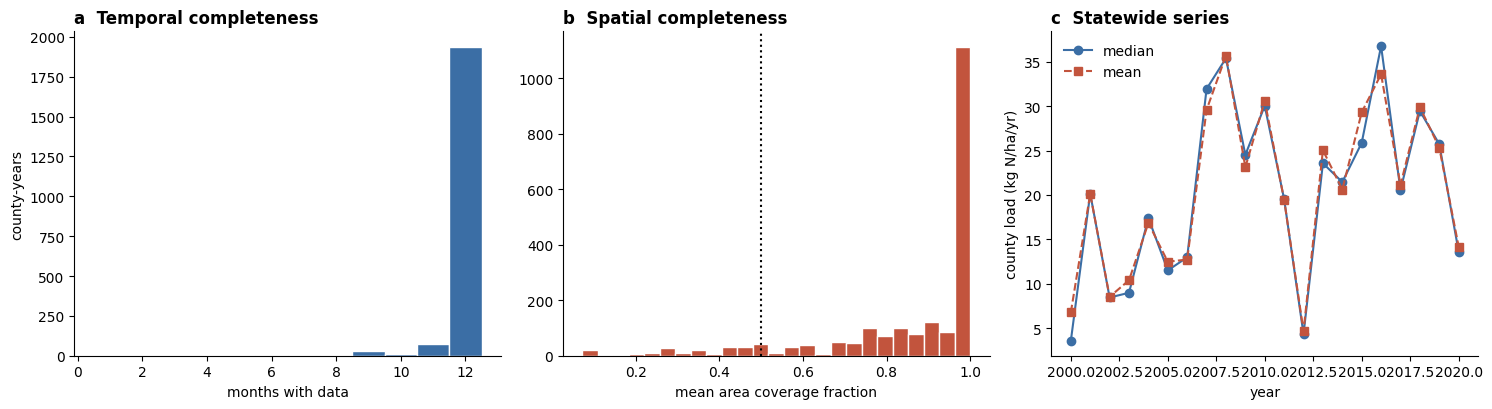

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].hist(ANN.months_available, bins=np.arange(0.5,13.5,1), color="#3b6ea5", edgecolor="w")
ax[0].set_xlabel("months with data"); ax[0].set_ylabel("county-years")
ax[0].set_title("a  Temporal completeness", loc="left", fontweight="bold")

ax[1].hist(ANN.mean_coverage_frac.dropna(), bins=25, color="#c2543d", edgecolor="w")
ax[1].axvline(0.5, ls=":", c="k"); ax[1].set_xlabel("mean area coverage fraction")
ax[1].set_title("b  Spatial completeness", loc="left", fontweight="bold")

yr = ANN[ANN.complete_year].groupby("Year").loading_kgha.agg(["median","mean"])
ax[2].plot(yr.index, yr["median"], "o-", c="#3b6ea5", label="median")
ax[2].plot(yr.index, yr["mean"],   "s--", c="#c2543d", label="mean")
ax[2].set_xlabel("year"); ax[2].set_ylabel("county load (kg N/ha/yr)")
ax[2].legend(frameon=False); ax[2].set_title("c  Statewide series", loc="left", fontweight="bold")

for a in ax: a.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(f"{CFG['OUT']}/fig_pipeline_qa.png", dpi=200)
plt.show()

## 10. Export

Everything the two papers need, plus the decision log.

In [32]:
exports = {
    "county_huc8_pieces.csv":                    PIECES,
    "county_huc8_coverage_audit.csv":            cov,
    "huc8_month_flow.csv":                       FLOW,
    "huc8_month_conc.csv":                       CONC,
    "county_month_load.csv":                     CM,
    "county_year_load.csv":                      ANN,
    "county_year_load_SENSITIVITY_intersects.csv": ANN_SENS,
    "county_year_panel_FINAL.csv":               PANEL,
    "county_year_model_frame.csv":               MODEL,
}
for name, df in exports.items():
    df.to_csv(f"{CFG['OUT']}/{name}", index=False)
    print(f"  {name:<48} {len(df):>8,} rows  {df.shape[1]:>3} cols")

# --- three load definitions, per review Point 1 ---
prim = ANN[ANN.complete_year & (ANN.mean_coverage_frac >= 0.5)]
full = ANN[ANN.complete_year]
prim.to_csv(f"{CFG['OUT']}/county_year_load_primary.csv", index=False)
full.to_csv(f"{CFG['OUT']}/county_year_load_fullsample.csv", index=False)
log(f"MEAN LOAD  primary(>=50% cov) {prim.loading_kgha.mean():.2f} | "
    f"full complete-year {full.loading_kgha.mean():.2f} | "
    f"full-area sensitivity {full.loading_kgha_fullarea.mean():.2f} kg N/ha/yr", decision=True)
log(f"primary sample: {len(prim)} county-years, {prim.CountyName.nunique()} counties "
    f"(dropped {len(full)-len(prim)} below 50% coverage)", decision=True)

meta = dict(built=datetime.now().isoformat(timespec="seconds"), config=CFG,
            counties_primary=int(PANEL.CountyName.nunique()),
            county_years=int(len(PANEL)),
            model_frame_rows=int(len(MODEL)),
            excluded_counties=NO_DATA,
            mean_load_kgha=float(ANN[ANN.complete_year].loading_kgha.mean()),
            mean_load_kgha_fullarea=float(ANN[ANN.complete_year].loading_kgha_fullarea.mean()),
            mean_fwmc_mgL=float(ANN[ANN.complete_year].FWMC_mgL.mean()))
json.dump(meta, open(f"{CFG['OUT']}/panel_metadata.json","w"), indent=2, default=str)
save_log()

print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)
for k in ["counties_primary","county_years","model_frame_rows",
          "mean_load_kgha","mean_fwmc_mgL","excluded_counties"]:
    print(f"  {k:<20} {meta[k]}")

  county_huc8_pieces.csv                                370 rows    5 cols
  county_huc8_coverage_audit.csv                         99 rows    4 cols
  huc8_month_flow.csv                                11,124 rows    5 cols
  huc8_month_conc.csv                                 9,842 rows    8 cols
  county_month_load.csv                              24,459 rows   13 cols
  county_year_load.csv                                2,058 rows   13 cols
  county_year_load_SENSITIVITY_intersects.csv         2,058 rows    4 cols
  county_year_panel_FINAL.csv                         2,058 rows   33 cols
  county_year_model_frame.csv                         1,750 rows   33 cols
[15:28:59] DECISION MEAN LOAD  primary(>=50% cov) 20.65 | full complete-year 20.18 | full-area sensitivity 18.36 kg N/ha/yr
[15:28:59] DECISION primary sample: 1801 county-years, 93 counties (dropped 137 below 50% coverage)

wrote out/decision_log.txt  (86 lines)

PIPELINE COMPLETE
  counties_primary     98
  county_years  

---

## What to check before using this panel

1. **Magnitude checks in 5.1 all read OK.** If mean county load sits outside 10-35 kg N/ha/yr,
   stop and find the unit error before going further.
2. **`exact-zero loads: 0`.** Any zero means something was filled rather than left missing.
3. **Area closure in section 1** between 0.98 and 1.02. Otherwise the HUC8 layer does not fully
   cover Iowa and every area weight is suspect.
4. **The excluded-county list.** Confirm it matches expectation and report the county count
   consistently in both manuscripts.
5. **Primary vs sensitivity correlation in 5.2.** If the two estimators diverge materially, that
   belongs in the paper as an uncertainty statement, not in a footnote.

## Next

- **Phase 2** — rerun the climate-gated analysis on `county_year_model_frame.csv` with the four
  corrections: leakage-free standardisation, true temporal split, bootstrap that refits, and the
  clipped counterfactual.
- **Phase 3** — the county/watershed mismatch tests, against the pre-specified decision rule.